
First 5 Records
   post_id   platform content_type  likes  comments  shares  reach  \
0        1  Instagram        Image   3569       101     590  49699   
1        2  Instagram         Post   4132       337     153  10109   
2        3    Twitter        Video   4756       373     453  28572   
3        4  Instagram         Reel    967       251     814   5905   
4        5   LinkedIn        Story   3553        28     553  29629   

   engagement_rate        date  
0             8.75  2026-03-23  
1             8.55  2026-05-07  
2             2.07  2026-05-07  
3             6.72  2026-04-01  
4             4.86  2026-04-21  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          500 non-null    int64  
 1   platform         500 non-null    object 
 2   content_type     500 non-null    object 
 3   like

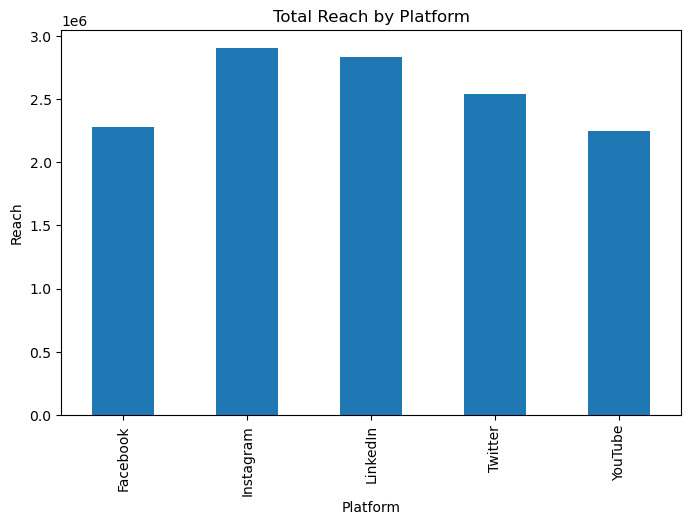


Average Engagement Rate
content_type
Image    8.725283
Post     8.422673
Reel     7.936705
Story    7.527788
Video    7.332174
Name: engagement_rate, dtype: float64


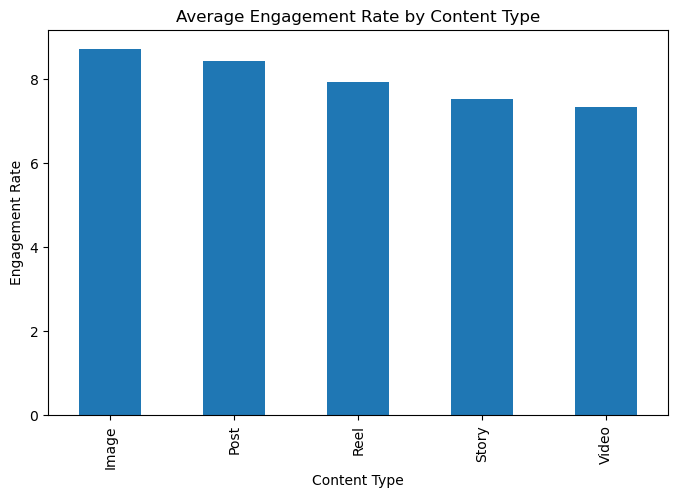


Top 10 Posts
     post_id   platform  reach
300      301    Twitter  49960
204      205    Twitter  49903
0          1  Instagram  49699
448      449    YouTube  49555
407      408    Twitter  49550
213      214  Instagram  49512
275      276  Instagram  49240
244      245    Twitter  49192
373      374    YouTube  49033
38        39   LinkedIn  48881


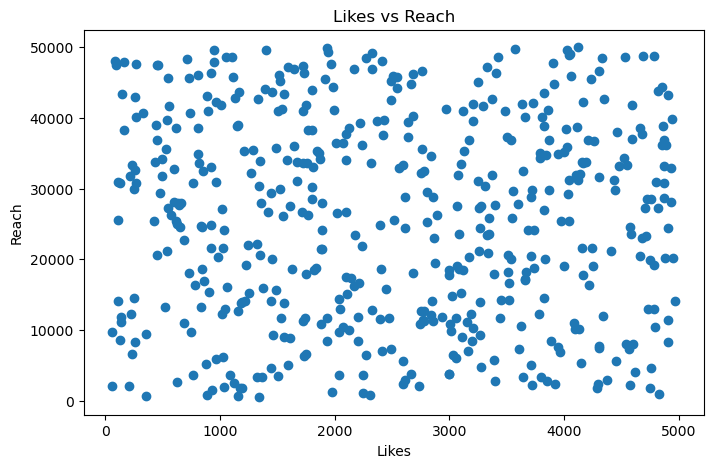


Total Reach: 12802548
Average Engagement Rate: 8.00%


In [4]:
# ==========================================
# Social Media Reach Analysis
# ==========================================

# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("social_media_reach.csv")

print("\nFirst 5 Records")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# Data Cleaning
# ==========================================

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values

for column in df.columns:

    if df[column].dtype == "object":

        df[column] = df[column].fillna(
            df[column].mode()[0]
        )

    else:

        df[column] = df[column].fillna(
            df[column].median()
        )

# ==========================================
# Total Reach by Platform
# ==========================================

platform_reach = df.groupby(
    "platform"
)["reach"].sum()

print("\nTotal Reach by Platform")
print(platform_reach)

plt.figure(figsize=(8,5))

platform_reach.plot(
    kind="bar"
)

plt.title(
    "Total Reach by Platform"
)

plt.xlabel(
    "Platform"
)

plt.ylabel(
    "Reach"
)

plt.show()

# ==========================================
# Average Engagement Rate
# ==========================================

engagement = df.groupby(
    "content_type"
)["engagement_rate"].mean()

print("\nAverage Engagement Rate")
print(engagement)

plt.figure(figsize=(8,5))

engagement.plot(
    kind="bar"
)

plt.title(
    "Average Engagement Rate by Content Type"
)

plt.xlabel(
    "Content Type"
)

plt.ylabel(
    "Engagement Rate"
)

plt.show()

# ==========================================
# Top 10 Posts by Reach
# ==========================================

top_posts = df.sort_values(
    by="reach",
    ascending=False
).head(10)

print("\nTop 10 Posts")
print(
top_posts[
[
"post_id",
"platform",
"reach"
]
]
)

# ==========================================
# Likes vs Reach
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["likes"],
    df["reach"]
)

plt.title(
    "Likes vs Reach"
)

plt.xlabel(
    "Likes"
)

plt.ylabel(
    "Reach"
)

plt.show()

# ==========================================
# Overall Statistics
# ==========================================

total_reach = df["reach"].sum()

average_engagement = df[
"engagement_rate"
].mean()

print(
f"\nTotal Reach: {total_reach}"
)

print(
f"Average Engagement Rate: {average_engagement:.2f}%"
)

# ==========================================
# End
# ==========================================